In [1]:
import sys
sys.path.insert(0, '../../mitsuba3/build/python')

from tqdm import trange, tqdm

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import drjit as dr
import mitsuba as mi

mi.set_variant('llvm_ad_rgb')

# Constants for training

SUN_PHI = dr.pi / 2
ALBEDO = 0.5

## Define original sphere to map

In [2]:
res = 100
theta = dr.linspace(mi.Float, 0, dr.pi/2 + 0.01*dr.pi, res)
phi = dr.linspace(mi.Float, 0, 2 * dr.pi, res)
theta, phi = dr.meshgrid(theta, phi)
st, ct = dr.sincos(theta)
sp, cp = dr.sincos(phi)

wi = mi.Vector3f(st * cp, st * sp, ct)
dr.eval(wi)

True

## Test a warp

In [3]:
def pdf_cosine_hemisphere(wi):
    return dr.inv_pi * dr.maximum(0.0, mi.Frame3f.cos_theta(wi))

def pdf_uniform_hemisphere(wi):
    return dr.inv_two_pi & (mi.Frame3f.cos_theta(wi) > 0.0)

def pdf_pow_cosine_hemisphere(wi, exp):
    return (1+exp) * mi.Frame3f.sin_theta(wi) * mi.Frame3f.cos_theta(wi) ** exp

def pdf_uniform_sphere(wi):
    return dr.inv_four_pi

def pdf(pdf_func, wi, mat):
    inv_mat = dr.rcp(mat)
    im_wi = inv_mat @ wi
    norm = dr.norm(im_wi)
    return dr.abs(dr.det(inv_mat)) * pdf_func(im_wi / norm) / (norm * norm * norm)

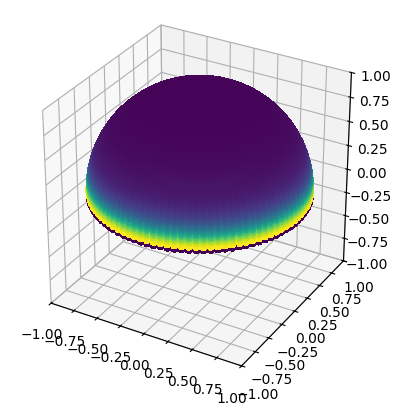

In [4]:
mat = mi.Matrix3f(
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 0.2]
)
pdf_out = pdf(pdf_uniform_hemisphere, wi, mat)

dr.eval(pdf_out)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(wi.x, wi.y, wi.z, c=pdf_out, antialiased=False, depthshade=False)
ax.set_box_aspect([1,1,1])  # Equal aspect ratio
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
plt.show()


## Setup optimization

In [5]:
""" Function that we want to fit"""
def get_lum(sky_rad, sky_params, cos_theta, gamma):
    cos_gamma = dr.cos(gamma)
    cos_gamma_2 = cos_gamma * cos_gamma

    res = dr.copy(sky_rad)
    for channel_idx in range(3):
        c1 = 1 + sky_params[channel_idx * 9 + 0] * dr.exp(sky_params[channel_idx * 9 + 1] / (cos_theta + 0.01))
        chi = (1 + cos_gamma_2) / ((1 + sky_params[channel_idx * 9 + 8]**2 - 2 * sky_params[channel_idx * 9 + 8] * cos_gamma)**1.5)
        c2 = sky_params[channel_idx * 9 + 2] + sky_params[channel_idx * 9 + 3] * dr.exp(sky_params[channel_idx * 9 + 4] * gamma) + \
                sky_params[channel_idx * 9 + 5] * cos_gamma_2 + sky_params[channel_idx * 9 + 6] * chi + sky_params[channel_idx * 9 + 7] * dr.safe_sqrt(cos_theta)

        res[channel_idx] *= c1 * c2
    
    return mi.luminance(res) * mi.MI_CIE_Y_NORMALIZATION & (cos_theta > 0)

In [6]:
""" Computes the normalization factor for the luminance function above """

@dr.syntax
def integrate_luminance(sun_dir, sky_rad, sky_params, cos_thetas, phis, quad_weights):

    i = mi.UInt32(0)
    total_lum = mi.Float(0)
    while i < dr.width(cos_thetas):
        # Gather inputs
        ct = dr.gather(mi.Float, cos_thetas, i)
        phi = dr.gather(mi.Float, phis, i)
        weight = dr.gather(mi.Float, quad_weights, i)

        # Compute direction
        st = dr.safe_sqrt(1 - ct**2)
        sp, cp = dr.sincos(phi)
        dir = mi.Vector3f(st * cp, st * sp, ct)
        gamma = dr.unit_angle(dir, sun_dir)

        res = get_lum(sky_rad, sky_params, ct, gamma)
        total_lum += st * weight * res
        i += 1
    
    return total_lum

def compute_norm_factor(sun_dir, sky_rad, sky_params):
    quad_points, quad_weights = mi.quad.gauss_legendre(200)
    cos_theta = quad_points * 0.5 + 0.5
    phi = dr.pi * (quad_points + 1)
    cos_theta, phi = dr.meshgrid(cos_theta, phi)
    phi_weights, cos_theta_weights = dr.meshgrid(quad_weights, quad_weights)
    weights = 0.5 * dr.pi * cos_theta_weights * phi_weights

    return dr.rcp(integrate_luminance(sun_dir, sky_rad, sky_params, cos_theta, phi, weights))

In [49]:
from vizsky_contrib import interpolate_dataset

def init_optimization_vars(sky_rad_dataset, sky_params_dataset, turb_res=10, sun_eta_res=30):
    nb_grid_points = turb_res * sun_eta_res

    # Define grid of turbidity and sun elevation angles
    turbs = dr.linspace(mi.Float, 1.0, 10.0, turb_res)
    sun_etas = dr.linspace(mi.Float, dr.deg2rad(2.0), dr.deg2rad(98.0), sun_eta_res)
    turbs, sun_etas = dr.meshgrid(turbs, sun_etas)
    tex_pos = mi.Point2f((turbs - 1) /(10 - 1), (dr.rad2deg(sun_etas) - 2) / (98-2))

    # Precompute sky radiance and parameters for each (turbidity, sun_eta) pair
    temp_sky_rad = dr.zeros(mi.Float, 3 * nb_grid_points)
    temp_sky_params = dr.zeros(mi.Float, 3 * 9 * nb_grid_points)
    for i, (turb, sun_eta) in tqdm(enumerate(zip(turbs.numpy(), sun_etas.numpy())), desc="Precomputing..."):
        sky_rad = interpolate_dataset(sky_rad_dataset, ALBEDO, turb, sun_eta).array
        temp = dr.gather(mi.Color3f, sky_rad, 0)
        dr.scatter(temp_sky_rad, temp, i)

        sky_params = interpolate_dataset(sky_params_dataset, ALBEDO, turb, sun_eta).array
        temp = dr.gather(mi.ArrayXf, sky_params, 0, shape=(3 * 9, 1))
        dr.scatter(temp_sky_params, temp, i)


    gather_idx = dr.arange(mi.UInt32, nb_grid_points)
    sky_rad = dr.gather(mi.Color3f, temp_sky_rad, gather_idx)
    sky_params = dr.gather(mi.ArrayXf, temp_sky_params, gather_idx, shape=(3 * 9, nb_grid_points))

    # Compute sun direction for each (turbidity, sun_eta) pair
    sun_thetas = dr.pi / 2 - sun_etas
    st, ct = dr.sincos(sun_thetas)
    sp, cp = dr.sincos(SUN_PHI)
    sun_dir = mi.Vector3f(st * cp, st * sp, ct)

    dr.eval(sky_rad, sky_params, sun_dir, tex_pos)

    # Compute normalization factor for each (turbidity, sun_eta) pair
    norm_factor = compute_norm_factor(sun_dir, sky_rad, sky_params)
    dr.eval(norm_factor)


    return sky_rad, sky_params, sun_dir, tex_pos, norm_factor

In [50]:
from vizsky_contrib import load_tensors

TRAINING_TURB_RES = 30
TRAINING_SUN_ETA_RES = 90

sky_rad_dataset, sky_params_dataset = load_tensors('../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin')

opt_vars = init_optimization_vars(
    sky_rad_dataset, sky_params_dataset,
    turb_res=TRAINING_TURB_RES, sun_eta_res=TRAINING_SUN_ETA_RES
)
dr.eval(opt_vars)
sky_rad, sky_params, sun_dir, tex_pos, norm_factor = opt_vars

Loading tensor data from "../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin" .. (540.0 KiB, 7 fields)


Precomputing...: 2700it [00:18, 142.52it/s]


### Vizalize a few luminance maps to check all is ok

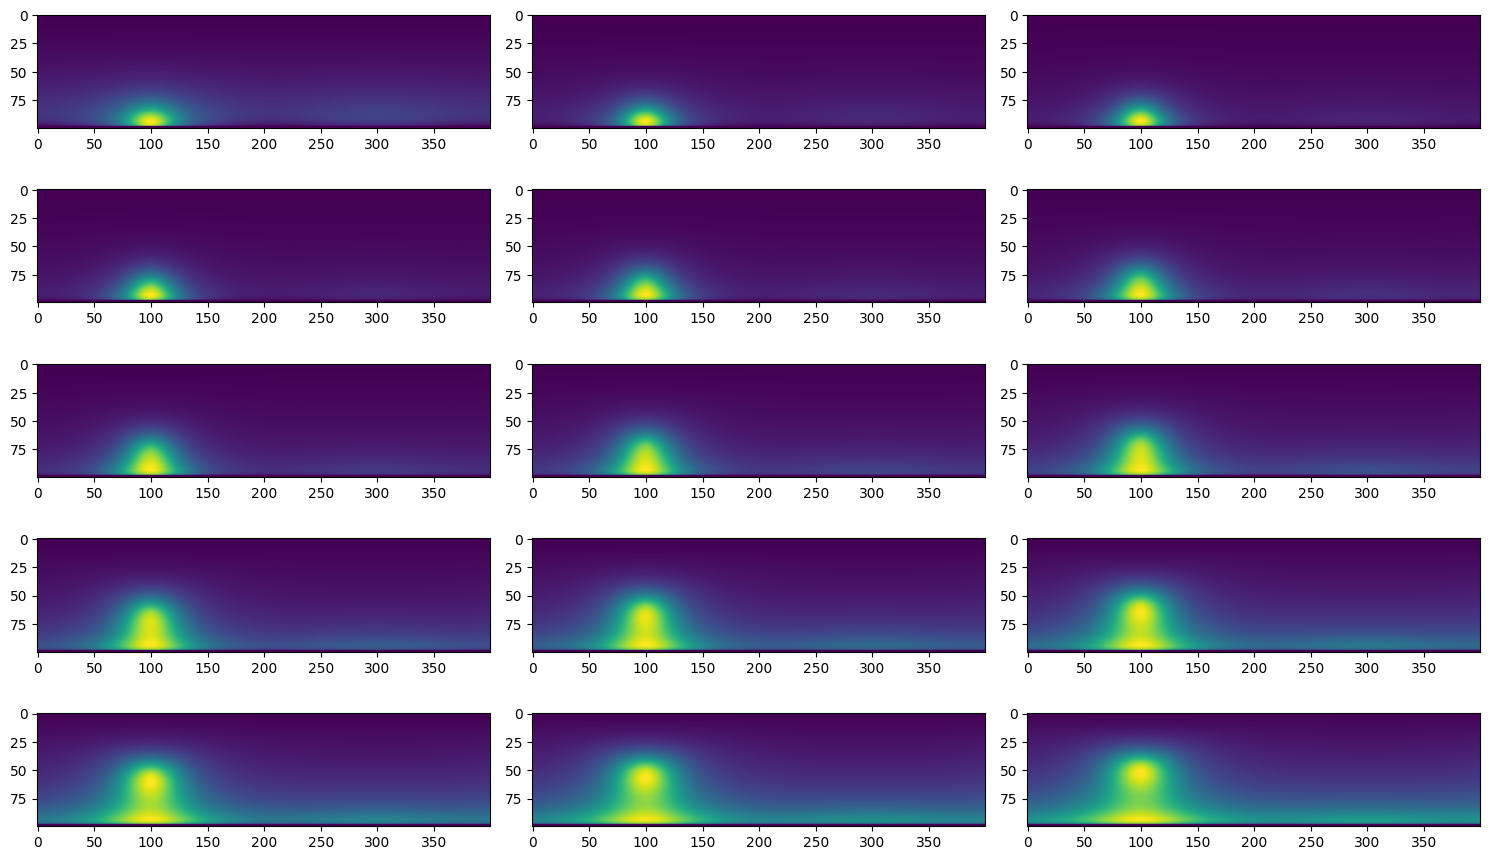

In [51]:
def viz_sky_map(ax, sun_dir, sky_rad, sky_params, norm_factor, idx):

    sun_dir = dr.gather(mi.Vector3f, sun_dir, idx)
    sky_rad = dr.gather(mi.Color3f, sky_rad, idx)
    sky_params = dr.gather(mi.ArrayXf, sky_params, idx, shape=(3 * 9, 1))
    norm_factor = dr.gather(mi.Float, norm_factor, idx)

    viz_res = (400, 100)
    phi, thetas = dr.meshgrid(
        dr.linspace(mi.Float, 0, 2 * dr.pi, viz_res[0]),
        dr.linspace(mi.Float, 0, dr.pi / 2 + 0.01 * dr.pi, viz_res[1])
    )
    st, ct = dr.sincos(thetas)
    sp, cp = dr.sincos(phi)
    wi = mi.Vector3f(st * cp, st * sp, ct)

    gamma = dr.unit_angle(wi, sun_dir)

    pdf = get_lum(sky_rad, sky_params, ct, gamma) * st * norm_factor
    pdf = mi.TensorXf(pdf, shape=viz_res[::-1])

    ax.imshow(pdf)



fig, axs = plt.subplots(5, 3, figsize=(15, 9))
axs = axs.flatten()
for i in range(5*3):
    viz_sky_map(axs[i], sun_dir, sky_rad, sky_params, norm_factor, TRAINING_SUN_ETA_RES * i + 15)

fig.tight_layout()
plt.show()

In [52]:
""" Function we will use to approximate the PDF """
def approximate_pdf(weights, wi):
    inv_mat = mi.Matrix3f([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, weights[0]]
    ])
    im_wi = inv_mat @ wi
    norm = dr.norm(im_wi)
    return dr.abs(dr.det(inv_mat)) * pdf_uniform_hemisphere(im_wi / norm) / (norm * norm * norm)

In [53]:
@dr.syntax
def compute_loss_per_gridpoint(tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi):
    weights = tex_weights.eval(tex_pos)

    ray_idx = mi.UInt32(0)
    total_loss = mi.Float(0)
    while dr.hint(ray_idx < dr.width(wi), max_iterations=-1):
        direction = dr.gather(mi.Vector3f, wi, ray_idx)
        cos_theta = mi.Frame3f.cos_theta(direction)
        gamma = dr.unit_angle(direction, sun_dir)

        target_pdf = get_lum(sky_rad, sky_params, cos_theta, gamma) * mi.Frame3f.sin_theta(direction) * norm_factor
        approx_pdf = approximate_pdf(weights, direction)
        
        total_loss += (approx_pdf - target_pdf) ** 2

        ray_idx += 1        

    return total_loss / dr.width(wi)

@dr.freeze
def compute_loss(tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi):
    loss = compute_loss_per_gridpoint(
        tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi
    )

    loss /= dr.width(tex_pos)

    dr.backward(loss)

    return dr.sum(loss)


Optimizing: 100%|██████████| 3000/3000 [00:46<00:00, 64.82it/s, Loss: [0.00825682]]


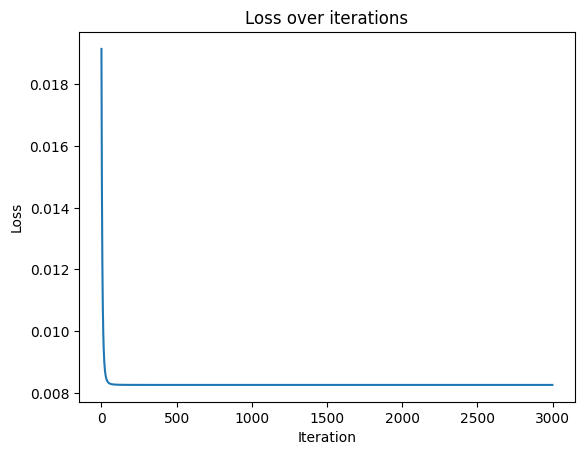

In [57]:
## Generate initial weights
turb_res = 10
sun_eta_res = 30
weights = dr.rng(42).normal(mi.TensorXf, shape=(turb_res, sun_eta_res, 1), loc=1, scale=0.2)
tex_weights = mi.Texture2f(weights, 
                           wrap_mode=dr.WrapMode.Clamp,
                           migrate=False)

opt = mi.ad.Adam(lr=0.05)
opt_key = "weights"
opt[opt_key] = weights

## Optimize
losses = []
iterations = trange(3000, desc="Optimizing")
for it in iterations:
    opt[opt_key] = dr.maximum(1e-5, opt[opt_key])
    tex_weights.set_tensor(opt[opt_key])


    loss = compute_loss(tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi)

    opt.step()

    if it % 100 == 0:
        iterations.set_postfix_str(f"Loss: {loss}")

    losses.append(loss)

optimal_weights = opt[opt_key]

plt.close()
cutoff = 0
losses_to_plot = losses[cutoff:]
plt.plot(np.arange(len(losses_to_plot)) + cutoff, losses_to_plot)
plt.title('Loss over iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

## Find the worse fitter

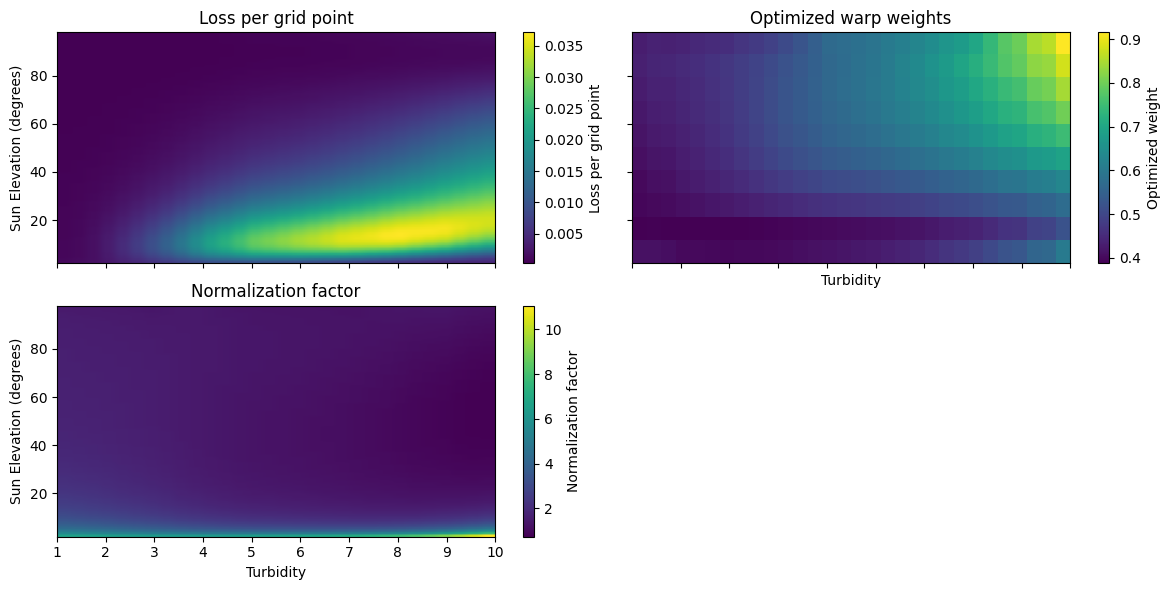

In [58]:
losses_per_point = compute_loss_per_gridpoint(
    tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi
)
losses_per_point = mi.TensorXf(losses_per_point, shape=(TRAINING_SUN_ETA_RES, TRAINING_TURB_RES))

fig, ax = plt.subplots(2, 2, figsize=(12,6), sharex=True, sharey=True)
ax = ax.flatten()

im = ax[0].imshow(losses_per_point, origin='lower', 
               extent=[1.0, 10.0, 2.0, 98.0], aspect='auto')
ax[0].set_title('Loss per grid point')
ax[0].set_ylabel('Sun Elevation (degrees)')
fig.colorbar(im, ax=ax[0], label='Loss per grid point')

im = ax[1].imshow(1/optimal_weights, origin='lower', 
               extent=[1.0, 10.0, 2.0, 98.0], aspect='auto')
ax[1].set_title('Optimized warp weights')
ax[1].set_xlabel('Turbidity')
fig.colorbar(im, ax=ax[1], label='Optimized weight')

norm_factor_tensor = mi.TensorXf(norm_factor, shape=(TRAINING_SUN_ETA_RES, TRAINING_TURB_RES))
im = ax[2].imshow(norm_factor_tensor, origin='lower', 
               extent=[1.0, 10.0, 2.0, 98.0], aspect='auto')
ax[2].set_title('Normalization factor')
ax[2].set_xlabel('Turbidity')
ax[2].set_ylabel('Sun Elevation (degrees)')
fig.colorbar(im, ax=ax[2], label='Normalization factor')

fig.delaxes(ax[3])
fig.tight_layout()
plt.show()